In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import kagglehub

path = kagglehub.dataset_download("manuelhettich/acne04")
print("الداتا انحفظت هنا:", path)

100%|██████████| 328M/328M [00:02<00:00, 171MB/s]

Extracting files...


الداتا انحفظت هنا: /root/.cache/kagglehub/datasets/manuelhettich/acne04/versions/13


In [3]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "    " * level
    images = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    print(f"{indent}📁 {os.path.basename(root)}  ({len(images)} صورة)")
    if level >= 2:
        dirs.clear()

📁 13  (0 صورة)
    📁 acne_1024  (0 صورة)
        📁 acne1_1024  (623 صورة)
        📁 acne3_1024  (96 صورة)
        📁 small_1024  (200 صورة)
        📁 acne3_512_selection  (16 صورة)
        📁 acne2_1024  (175 صورة)
        📁 small_1024_renamed  (200 صورة)
        📁 acne0_1024  (483 صورة)
        📁 all_1024  (1406 صورة)


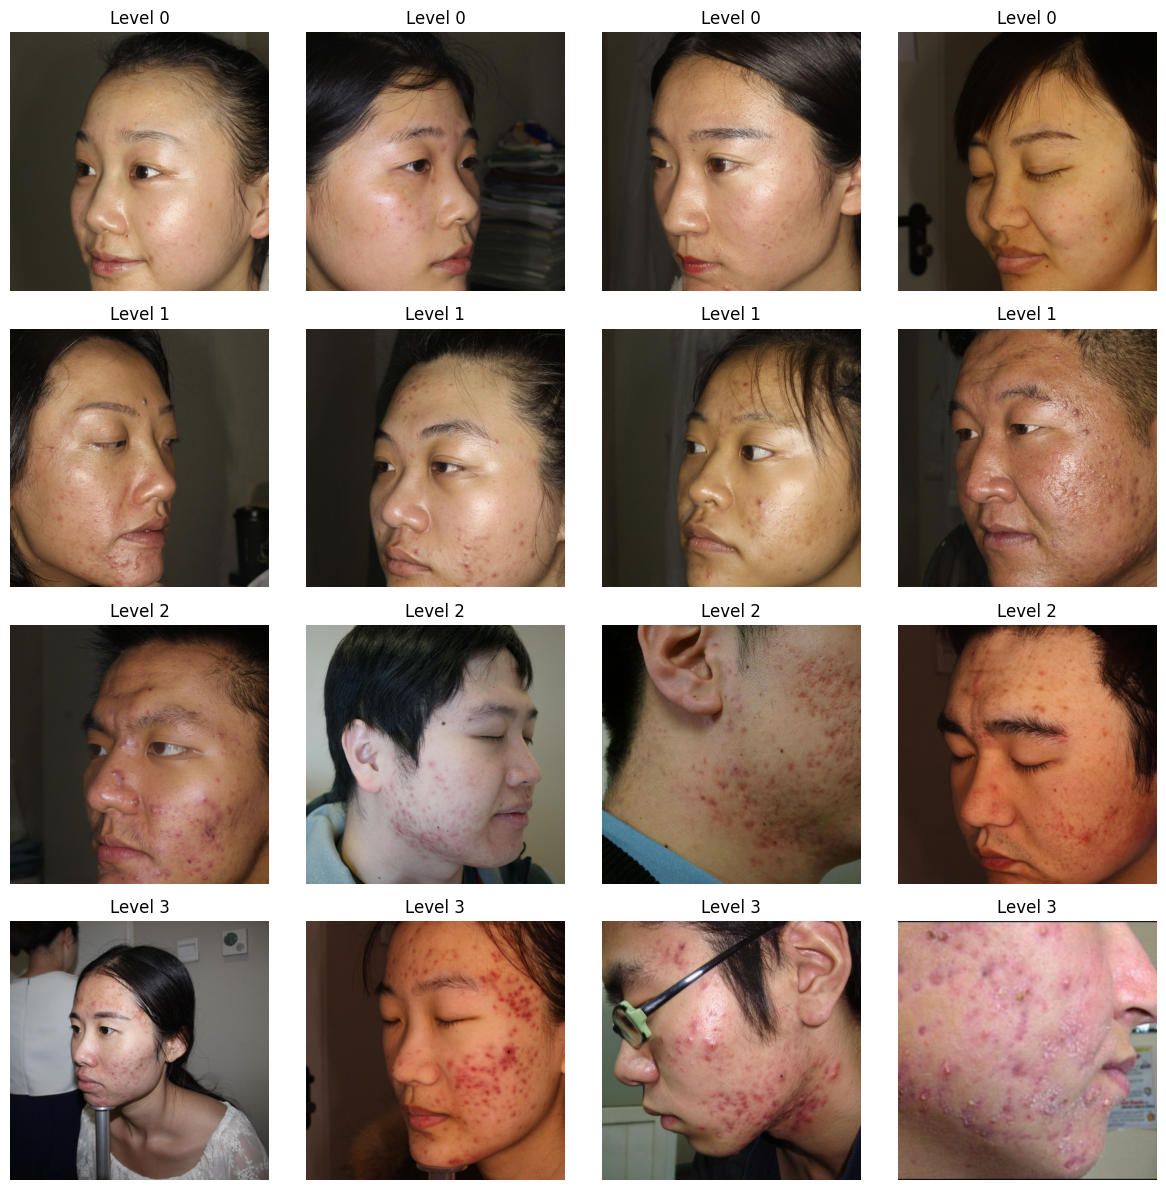

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

base = os.path.join(path, "acne_1024")
classes = ["acne0_1024", "acne1_1024", "acne2_1024", "acne3_1024"]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, cls in enumerate(classes):
    files = os.listdir(os.path.join(base, cls))[:4]
    for j, f in enumerate(files):
        img = Image.open(os.path.join(base, cls, f))
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        axes[i, j].set_title(f"Level {i}")
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from collections import Counter

filepaths, labels = [], []
for i, cls in enumerate(classes):
    folder = os.path.join(base, cls)
    for f in os.listdir(folder):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            filepaths.append(os.path.join(folder, f))
            labels.append(i)

train_x, temp_x, train_y, temp_y = train_test_split(
    filepaths, labels, test_size=0.30, stratify=labels, random_state=42)
val_x, test_x, val_y, test_y = train_test_split(
    temp_x, temp_y, test_size=0.50, stratify=temp_y, random_state=42)

print("Train:", len(train_x), sorted(Counter(train_y).items()))
print("Val:  ", len(val_x),   sorted(Counter(val_y).items()))
print("Test: ", len(test_x),  sorted(Counter(test_y).items()))

Train: 963 [(0, 338), (1, 436), (2, 122), (3, 67)]
Val:   207 [(0, 72), (1, 93), (2, 27), (3, 15)]
Test:  207 [(0, 73), (1, 94), (2, 26), (3, 14)]


In [6]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE = 224
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img, label

def make_ds(x, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(len(x), seed=42)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_ds(train_x, train_y, shuffle=True)
val_ds   = make_ds(val_x, val_y)
test_ds  = make_ds(test_x, test_y)

weights = compute_class_weight("balanced", classes=np.unique(train_y), y=train_y)
class_weights = dict(enumerate(weights))

print("الصور جاهزة ✅")
print("أوزان المستويات:", {k: round(v, 2) for k, v in class_weights.items()})

الصور جاهزة ✅
أوزان المستويات: {0: np.float64(0.71), 1: np.float64(0.55), 2: np.float64(1.97), 3: np.float64(3.59)}


In [7]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./127.5, offset=-1)(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("الموديل جاهز ✅")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
الموديل جاهز ✅


In [8]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 203ms/step - accuracy: 0.3053 - loss: 1.5317 - val_accuracy: 0.4831 - val_loss: 1.0847
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.3904 - loss: 1.2617 - val_accuracy: 0.5411 - val_loss: 0.9595
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.4590 - loss: 1.0754 - val_accuracy: 0.5024 - val_loss: 1.0220
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 206ms/step - accuracy: 0.4621 - loss: 1.0556 - val_accuracy: 0.5217 - val_loss: 0.9461
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - accuracy: 0.5036 - loss: 0.9714 - val_accuracy: 0.4686 - val_loss: 0.9712
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step - accuracy: 0.5099 - loss: 0.9049 - val_accuracy: 0.4444 - val_loss: 1.0965
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - accuracy: 0.5182 - loss: 0.9302 - val_accuracy: 0.4879 - val_loss: 1.0058
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.5379 - loss: 0.9058 - val_accuracy: 0

In [9]:
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 191ms/step - accuracy: 0.2669 - loss: 1.5312 - val_accuracy: 0.5604 - val_loss: 0.8655
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - accuracy: 0.3198 - loss: 1.3426 - val_accuracy: 0.5652 - val_loss: 0.8821
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.3904 - loss: 1.2044 - val_accuracy: 0.5700 - val_loss: 0.9006
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 0.4476 - loss: 1.0704 - val_accuracy: 0.5845 - val_loss: 0.9003


In [10]:
early_stop_fine = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop_fine]
)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 233ms/step - accuracy: 0.3053 - loss: 1.3147 - val_accuracy: 0.5652 - val_loss: 0.8732
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 208ms/step - accuracy: 0.3780 - loss: 1.1911 - val_accuracy: 0.5652 - val_loss: 0.8775
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.4289 - loss: 1.0546 - val_accuracy: 0.5749 - val_loss: 0.8878
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.4590 - loss: 1.0077 - val_accuracy: 0.5894 - val_loss: 0.8783
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.4922 - loss: 0.9728 - val_accuracy: 0.5797 - val_loss: 0.8719
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.5036 - loss: 0.9223 - val_accuracy: 0.5845 - val_loss: 0.8602
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 0.5244 - loss: 0.8951 - val_accuracy: 0.5845 - val_loss: 0.8585
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step - accuracy: 0.5016 - loss: 0.8994 - val_accuracy: 0.

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 209ms/step
              precision    recall  f1-score   support

     Level 0       0.61      0.90      0.73        73
     Level 1       0.71      0.43      0.53        94
     Level 2       0.52      0.62      0.56        26
     Level 3       0.82      0.64      0.72        14

    accuracy                           0.63       207
   macro avg       0.66      0.65      0.64       207
weighted avg       0.66      0.63      0.62       207



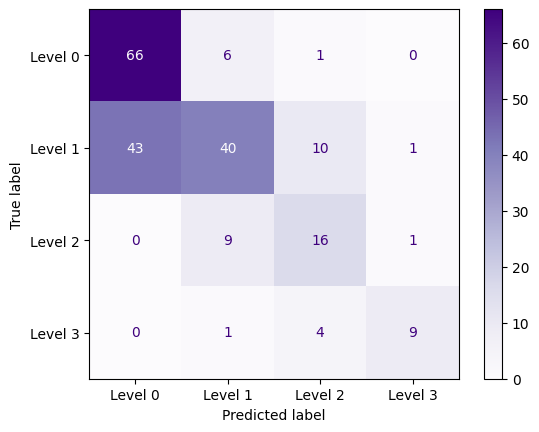

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(test_ds), axis=1)
y_true = np.array(test_y)
names = ["Level 0", "Level 1", "Level 2", "Level 3"]

print(classification_report(y_true, y_pred, target_names=names))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=names).plot(cmap="Purples")
plt.show()

In [18]:
from google.colab import drive
drive.mount('/content/drive')

save_dir = "/content/drive/MyDrive/Flawless_AI"
os.makedirs(save_dir, exist_ok=True)
model.save(f"{save_dir}/acne_model_448.keras")

print("الموديل انحفظ ✅")

ValueError: mount failed

In [19]:
model.save("/content/acne_model_448.keras")
print("انحفظ مؤقتاً ✅")

انحفظ مؤقتاً ✅


In [20]:
from google.colab import files
files.download("/content/acne_model_448.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
IMG_SIZE = 448
BATCH = 16

train_ds = make_ds(train_x, train_y, shuffle=True)
val_ds   = make_ds(val_x, val_y)
test_ds  = make_ds(test_x, test_y)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation_448")

base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./127.5, offset=-1)(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation="softmax")(x)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True)]
)

/tmp/ipykernel_1776/1096968908.py:15: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 16s 166ms/step - accuracy: 0.3479 - loss: 1.3155 - val_accuracy: 0.5266 - val_loss: 1.0548
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.4590 - loss: 1.1008 - val_accuracy: 0.5556 - val_loss: 0.9662
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.5036 - loss: 0.9802 - val_accuracy: 0.5507 - val_loss: 0.9308
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step - accuracy: 0.5057 - loss: 0.9627 - val_accuracy: 0.6232 - val_loss: 0.8829
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - accuracy: 0.5618 - loss: 0.8945 - val_accuracy: 0.5507 - val_loss: 0.8904
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.5576 - loss: 0.8772 - val_accuracy: 0.5072 - val_loss: 0.9637
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - accuracy: 0.5722 - loss: 0.8434 - val_accuracy: 0.5459 - val_loss: 0.8889
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.5742 - loss: 0.8223 - val_accuracy:

In [16]:
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True)]
)

Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 27s 217ms/step - accuracy: 0.1952 - loss: 1.5856 - val_accuracy: 0.6522 - val_loss: 0.8482
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.4901 - loss: 1.0125 - val_accuracy: 0.6522 - val_loss: 0.8717
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.5358 - loss: 0.9112 - val_accuracy: 0.6570 - val_loss: 0.8024
Epoch 4/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.5483 - loss: 0.8722 - val_accuracy: 0.6812 - val_loss: 0.7750
Epoch 5/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.5441 - loss: 0.8622 - val_accuracy: 0.6425 - val_loss: 0.7536
Epoch 6/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 175ms/step - accuracy: 0.5919 - loss: 0.7793 - val_accuracy: 0.6280 - val_loss: 0.7537
Epoch 7/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.5992 - loss: 0.7803 - val_accuracy: 0.6135 - val_loss: 0.7544
Epoch 8/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.6189 - loss: 0.7233 - val_accu